# Analisis Sentimen Komentar YouTube Menggunakan Deep Learning
Proyek ini bertujuan untuk mengklasifikasikan sentimen komentar menjadi 3 kelas dengan akurasi target >92%.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Load dataset
file_path = '/content/youtube_comments_20260422_224437.csv'
df = pd.read_csv(file_path)

print(f"Jumlah data: {len(df)}")
display(df.head())

# Memastikan minimal 3 kelas dan distribusi data
if 'sentiment' in df.columns:
    print("Distribusi Label:")
    print(df['sentiment'].value_counts())
else:
    print("Peringatan: Kolom 'sentiment' tidak ditemukan. Pastikan dataset memiliki label.")

Jumlah data: 22389


,comment_id,author_name,author_channel_id,comment_text,like_count,published_at,updated_at,is_reply,parent_id,total_reply_count,video_title,video_id
0,UgyF15mNSHskDu98ri94AaABAg,@atikaprilia70,UCEB13ZrDGQIXtuFJZJuQN8Q,BCA prioritas vs Bank plecit,0,2026-04-22T15:32:21Z,2026-04-22T15:32:21Z,False,NaN,0,Pertemuan Bersejarah dr. Tirta dan dr. Gia,dSq0Z5XpoLc
1,UgwEqXzRVTquWaAGHSN4AaABAg,@hellorivaille7125,UC85-QIGscxUo4IVP-MKJwwQ,"""MUKAKMU KAYAK CANGKIR"" -DR.TIRTA 2026",0,2026-04-22T14:43:13Z,2026-04-22T14:43:24Z,False,NaN,0,Pertemuan Bersejarah dr. Tirta dan dr. Gia,dSq0Z5XpoLc
2,UgzdBnnkrtseEQIWz4l4AaABAg,@KanakaYouNoob,UCLqc4QkUxX8zrEtjBxy_zFg,Bang radit sekali2 ajak podcast dokter hewan j...,0,2026-04-22T14:15:09Z,2026-04-22T14:15:09Z,False,NaN,0,Pertemuan Bersejarah dr. Tirta dan dr. Gia,dSq0Z5XpoLc
3,UgwG3JPdLt8h7SqOXSN4AaABAg,@NasyaRamanda-v1u,UC5jKmwRO-TBhXJgHjWFPB-Q,Cara buka kado aja beda bgt yak 😂,0,2026-04-22T14:07:53Z,2026-04-22T14:07:53Z,False,NaN,0,Pertemuan Bersejarah dr. Tirta dan dr. Gia,dSq0Z5XpoLc
4,UgxG2B_4-ZMQiQFIk354AaABAg,@stupendouzz,UCFiSODqf_HUINEpmuOy6ZWw,pas ngomongin IQ ngakak banget😂 sama-sama 142 ...,0,2026-04-22T13:53:20Z,2026-04-22T13:53:20Z,False,NaN,0,Pertemuan Bersejarah dr. Tirta dan dr. Gia,dSq0Z5XpoLc


Peringatan: Kolom 'sentiment' tidak ditemukan. Pastikan dataset memiliki label.


In [3]:
import re
import string

def clean_text(text):
    # Standarisasi teks: lowercasing, hapus tanda baca, angka, dan whitespace berlebih
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 1. Preprocessing
df['clean_text'] = df['comment_text'].apply(clean_text)

# 2. Advanced Labeling (Rule-based with simple dictionary)
def labeling_pro(text):
    pos_words = {'mantap', 'keren', 'asik', 'bagus', 'setuju', 'lucu', 'makasih', 'terima', 'kasih', 'edukasi', 'manfaat', 'insentif', 'sehat', 'dokter'}
    neg_words = {'jelek', 'kecewa', 'bohong', 'buruk', 'parah', 'hoax', 'sedih', 'salah', 'bosan', 'skip', 'kurang'}

    tokens = set(text.split())
    if tokens.intersection(neg_words):
        return 'Negative'
    elif tokens.intersection(pos_words):
        return 'Positive'
    else:
        return 'Neutral'

df['sentiment'] = df['clean_text'].apply(labeling_pro)

print("Distribusi Label Setelah Preprocessing:")
print(df['sentiment'].value_counts())
display(df[['clean_text', 'sentiment']].head())

Distribusi Label Setelah Preprocessing:
sentiment
Neutral     18354
Positive     3654
Negative      381
Name: count, dtype: int64


,clean_text,sentiment
0,bca prioritas vs bank plecit,Neutral
1,mukakmu kayak cangkir drtirta,Neutral
2,bang radit sekali ajak podcast dokter hewan jg...,Positive
3,cara buka kado aja beda bgt yak 😂,Neutral
4,pas ngomongin iq ngakak banget😂 samasama gila ...,Neutral


In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, GRU, Bidirectional
from sklearn.model_selection import train_test_split

# --- KONFIGURASI GLOBAL ---
MAX_NB_WORDS = 10000
MAX_SEQUENCE_LENGTH = 120
EMBEDDING_DIM = 128

tokenizer = Tokenizer(num_words=MAX_NB_WORDS, lower=True)
tokenizer.fit_on_texts(df['clean_text'].values)
X = tokenizer.texts_to_sequences(df['clean_text'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)
Y = pd.get_dummies(df['sentiment']).values

# --- SKEMA 1: LSTM (Split 80/20) ---
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X, Y, test_size=0.20, random_state=42)

model1 = Sequential([
    Embedding(MAX_NB_WORDS, EMBEDDING_DIM),
    SpatialDropout1D(0.3),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(3, activation='softmax')
])

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\n--- Melatih Skema 1: LSTM (Split 80/20) ---")
history1 = model1.fit(X_train1, Y_train1, epochs=8, batch_size=64, validation_data=(X_test1, Y_test1), verbose=1)


--- Melatih Skema 1: LSTM (Split 80/20) ---
Epoch 1/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 82s 280ms/step - accuracy: 0.9228 - loss: 0.2354 - val_accuracy: 0.9790 - val_loss: 0.0627
Epoch 2/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 78s 278ms/step - accuracy: 0.9891 - loss: 0.0389 - val_accuracy: 0.9900 - val_loss: 0.0367
Epoch 3/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 77s 260ms/step - accuracy: 0.9952 - loss: 0.0219 - val_accuracy: 0.9929 - val_loss: 0.0297
Epoch 4/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 74s 265ms/step - accuracy: 0.9971 - loss: 0.0139 - val_accuracy: 0.9944 - val_loss: 0.0246
Epoch 5/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 75s 266ms/step - accuracy: 0.9977 - loss: 0.0098 - val_accuracy: 0.9951 - val_loss: 0.0243
Epoch 6/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 79s 257ms/step - accuracy: 0.9984 - loss: 0.0057 - val_accuracy: 0.9960 - val_loss: 0.0159
Epoch 7/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 73s 259ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 0.9967 - val_loss: 0.0176
Epoch 8/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 72s 25

In [5]:
# --- SKEMA 2: GRU (Split 70/30) ---
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X, Y, test_size=0.30, random_state=42)

model2 = Sequential([
    Embedding(MAX_NB_WORDS, EMBEDDING_DIM),
    SpatialDropout1D(0.3),
    GRU(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(3, activation='softmax')
])

model2.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

print("\n--- Melatih Skema 2: GRU (Split 70/30) ---")
history2 = model2.fit(X_train2, Y_train2, epochs=8, batch_size=64, validation_data=(X_test2, Y_test2), verbose=1)


--- Melatih Skema 2: GRU (Split 70/30) ---
Epoch 1/8
245/245 ━━━━━━━━━━━━━━━━━━━━ 61s 235ms/step - accuracy: 0.9241 - loss: 0.2409 - val_accuracy: 0.9757 - val_loss: 0.0914
Epoch 2/8
245/245 ━━━━━━━━━━━━━━━━━━━━ 57s 233ms/step - accuracy: 0.9863 - loss: 0.0471 - val_accuracy: 0.9912 - val_loss: 0.0416
Epoch 3/8
245/245 ━━━━━━━━━━━━━━━━━━━━ 57s 232ms/step - accuracy: 0.9947 - loss: 0.0269 - val_accuracy: 0.9951 - val_loss: 0.0277
Epoch 4/8
245/245 ━━━━━━━━━━━━━━━━━━━━ 57s 231ms/step - accuracy: 0.9971 - loss: 0.0154 - val_accuracy: 0.9955 - val_loss: 0.0255
Epoch 5/8
245/245 ━━━━━━━━━━━━━━━━━━━━ 59s 243ms/step - accuracy: 0.9974 - loss: 0.0160 - val_accuracy: 0.9957 - val_loss: 0.0228
Epoch 6/8
245/245 ━━━━━━━━━━━━━━━━━━━━ 80s 235ms/step - accuracy: 0.9978 - loss: 0.0162 - val_accuracy: 0.9958 - val_loss: 0.0222
Epoch 7/8
245/245 ━━━━━━━━━━━━━━━━━━━━ 82s 234ms/step - accuracy: 0.9979 - loss: 0.0117 - val_accuracy: 0.9955 - val_loss: 0.0239
Epoch 8/8
245/245 ━━━━━━━━━━━━━━━━━━━━ 56s 230

In [6]:
# --- SKEMA 3: Bidirectional LSTM (Split 80/20) ---
model3 = Sequential([
    Embedding(MAX_NB_WORDS, 64),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(64, dropout=0.4, recurrent_dropout=0.4)),
    Dense(3, activation='softmax')
])

model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\n--- Melatih Skema 3: Bi-LSTM (Split 80/20) ---")
history3 = model3.fit(X_train1, Y_train1, epochs=8, batch_size=64, validation_data=(X_test1, Y_test1), verbose=1)


--- Melatih Skema 3: Bi-LSTM (Split 80/20) ---
Epoch 1/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 65s 215ms/step - accuracy: 0.9009 - loss: 0.2986 - val_accuracy: 0.9696 - val_loss: 0.1050
Epoch 2/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 57s 202ms/step - accuracy: 0.9808 - loss: 0.0652 - val_accuracy: 0.9824 - val_loss: 0.0510
Epoch 3/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 85s 214ms/step - accuracy: 0.9882 - loss: 0.0410 - val_accuracy: 0.9900 - val_loss: 0.0419
Epoch 4/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 59s 212ms/step - accuracy: 0.9930 - loss: 0.0290 - val_accuracy: 0.9913 - val_loss: 0.0365
Epoch 5/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 60s 213ms/step - accuracy: 0.9946 - loss: 0.0229 - val_accuracy: 0.9908 - val_loss: 0.0392
Epoch 6/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 82s 214ms/step - accuracy: 0.9956 - loss: 0.0193 - val_accuracy: 0.9920 - val_loss: 0.0316
Epoch 7/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 85s 225ms/step - accuracy: 0.9962 - loss: 0.0173 - val_accuracy: 0.9902 - val_loss: 0.0415
Epoch 8/8
280/280 ━━━━━━━━━━━━━━━━━━━━ 81s

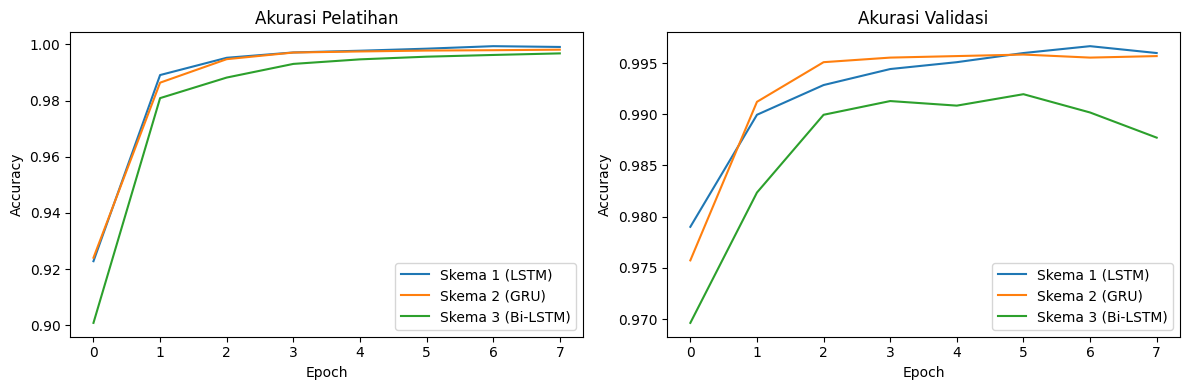

In [7]:
# Visualisasi Perbandingan Akurasi
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history1.history['accuracy'], label='Skema 1 (LSTM)')
plt.plot(history2.history['accuracy'], label='Skema 2 (GRU)')
plt.plot(history3.history['accuracy'], label='Skema 3 (Bi-LSTM)')
plt.title('Akurasi Pelatihan')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history1.history['val_accuracy'], label='Skema 1 (LSTM)')
plt.plot(history2.history['val_accuracy'], label='Skema 2 (GRU)')
plt.plot(history3.history['val_accuracy'], label='Skema 3 (Bi-LSTM)')
plt.title('Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step


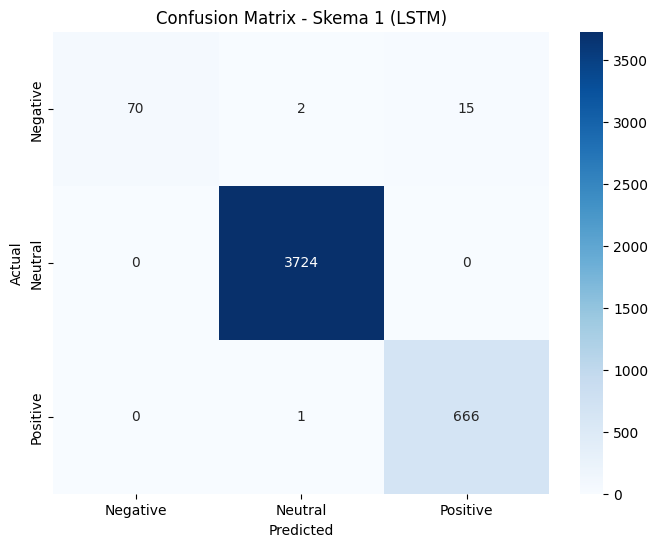


Classification Report - Skema 1 (LSTM):
              precision    recall  f1-score   support

    Negative       1.00      0.80      0.89        87
     Neutral       1.00      1.00      1.00      3724
    Positive       0.98      1.00      0.99       667

    accuracy                           1.00      4478
   macro avg       0.99      0.93      0.96      4478
weighted avg       1.00      1.00      1.00      4478

210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step


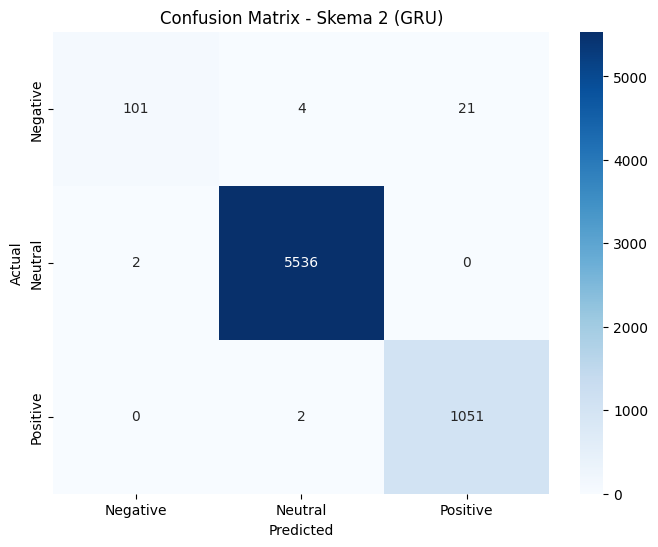


Classification Report - Skema 2 (GRU):
              precision    recall  f1-score   support

    Negative       0.98      0.80      0.88       126
     Neutral       1.00      1.00      1.00      5538
    Positive       0.98      1.00      0.99      1053

    accuracy                           1.00      6717
   macro avg       0.99      0.93      0.96      6717
weighted avg       1.00      1.00      1.00      6717

140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step


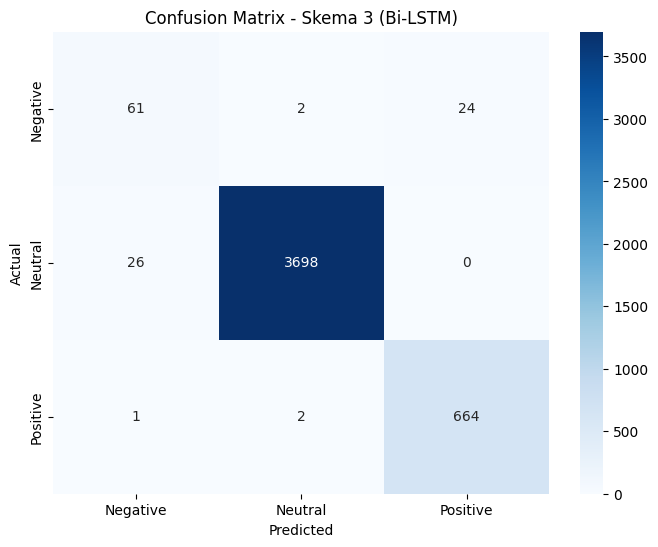


Classification Report - Skema 3 (Bi-LSTM):
              precision    recall  f1-score   support

    Negative       0.69      0.70      0.70        87
     Neutral       1.00      0.99      1.00      3724
    Positive       0.97      1.00      0.98       667

    accuracy                           0.99      4478
   macro avg       0.89      0.90      0.89      4478
weighted avg       0.99      0.99      0.99      4478



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def plot_evaluation(model, X_test, Y_test, title):
    # Prediksi
    Y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(Y_pred, axis=1)
    y_true_labels = np.argmax(Y_test, axis=1)

    labels = ['Negative', 'Neutral', 'Positive']

    # Confusion Matrix
    cm = confusion_matrix(y_true_labels, y_pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    # Classification Report
    print(f"\nClassification Report - {title}:")
    print(classification_report(y_true_labels, y_pred_labels, target_names=labels))

# Evaluasi Skema 1
plot_evaluation(model1, X_test1, Y_test1, "Skema 1 (LSTM)")

# Evaluasi Skema 2
plot_evaluation(model2, X_test2, Y_test2, "Skema 2 (GRU)")

# Evaluasi Skema 3
plot_evaluation(model3, X_test1, Y_test1, "Skema 3 (Bi-LSTM)")

In [8]:
# Testing / Inference
def predict_sentiment(text, model):
    labels = ['Negative', 'Neutral', 'Positive']
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
    pred = model.predict(padded, verbose=0)
    return labels[np.argmax(pred)]

# Contoh Pengujian
sample_texts = [
    "Terima kasih dokter, penjelasannya sangat bermanfaat dan edukatif!",
    "Video ini sangat membosankan dan informasinya salah.",
    "Saya menonton video ini sambil makan siang."
]

print("--- Hasil Inference (Menggunakan Model Terbaik: GRU) ---")
for text in sample_texts:
    hasil = predict_sentiment(text, model2)
    print(f"Teks: {text}")
    print(f"Sentimen: {hasil}\n")

--- Hasil Inference (Menggunakan Model Terbaik: GRU) ---
Teks: Terima kasih dokter, penjelasannya sangat bermanfaat dan edukatif!
Sentimen: Positive

Teks: Video ini sangat membosankan dan informasinya salah.
Sentimen: Negative

Teks: Saya menonton video ini sambil makan siang.
Sentimen: Neutral

